# Proteomics QC: PCA, Pairwise Correlations, and Sample Intensity Boxplots (No Imputation)

This notebook performs QC and exploratory analysis on the quantitative proteomics matrix exported from OmicsQ after upstream preprocessing.

## Reproducibility notes
- Run cells from top to bottom in a fresh kernel.
- The notebook assumes a repository layout in which raw or processed inputs are stored under `data/` and generated files are written to `analysis_outputs/`.
- Update `DATA_PATH` below if your exported file has a different name.
- The analysis expects sample columns named `C_1 ... C_9` for controls and `AA_1 ... AA_9` for acid-adapted cells.
- No random subsampling is used; PCA is deterministic because `random_state=0` is set.
- Figures are saved with relative paths so the notebook can be rerun on another machine or after archive upload.

## Input dataset
Expected input: a comma-separated quantitative matrix exported from OmicsQ, here referenced as `data/OmicsQ/OmicsQResults2026-01-08_median_normalized.csv`.

## Outputs
This notebook writes QC figures to `output/figures/`.



In [1]:
from pathlib import Path
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import font_manager
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Patch
import sklearn

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 14,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.titlesize": 14,
    "savefig.bbox": "tight",
})

# ------------------------------------------------------------------
# Project paths
# ------------------------------------------------------------------

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "workflow" else NOTEBOOK_DIR

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "output"
FIGURE_DIR = OUTPUT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Update this path if the exported OmicsQ file is renamed in your archive/repository.
DATA_PATH = DATA_DIR / "OmicsQ" / "OmicsQResults.csv"

assert DATA_PATH.exists(), f"Input file not found: {DATA_PATH}"

print(f"Working directory: {NOTEBOOK_DIR}")
print(f"Input file: {DATA_PATH}")
print(f"Figure output directory: {FIGURE_DIR}")
print(f"pandas {pd.__version__} | numpy {np.__version__} | scikit-learn {sklearn.__version__}")

Working directory: /home/bnair/Desktop/analysis/aacs_proteomics
Input file: /home/bnair/Desktop/analysis/aacs_proteomics/data/OmicsQ/OmicsQResults.csv
Figure output directory: /home/bnair/Desktop/analysis/aacs_proteomics/output/figures
pandas 3.0.0 | numpy 2.4.1 | scikit-learn 1.6.1


In [2]:
# --- Load data ---
df = pd.read_csv(DATA_PATH)

# If first column is NOT numeric, treat it as an identifier column and set as index
if not pd.api.types.is_numeric_dtype(df.iloc[:, 0]):
    df = df.set_index(df.columns[0])

sample_cols = [c for c in df.columns if isinstance(c, str)]
control_cols = [c for c in sample_cols if c.startswith("C_")]
acid_cols    = [c for c in sample_cols if c.startswith("AA_")]

assert control_cols, "No control columns detected with prefix 'C_'."
assert acid_cols, "No acid-adapted columns detected with prefix 'AA_'."

X = df[control_cols + acid_cols].apply(pd.to_numeric, errors="coerce")

print("Data shape (features x samples):", X.shape)
print("Control samples:", len(control_cols))
print("Acid-adapted samples:", len(acid_cols))
print("Total missing values:", int(X.isna().sum().sum()))



Data shape (features x samples): (2585, 18)
Control samples: 9
Acid-adapted samples: 9
Total missing values: 2754


In [3]:
# --- Optional log2 transform ---
DO_LOG2 = False
X_proc = X.copy()

if DO_LOG2:
    X_proc[X_proc <= 0] = np.nan
    X_proc = np.log2(X_proc)

print("After log2 (if applied):")
print("Total missing values:", int(X_proc.isna().sum().sum()))


After log2 (if applied):
Total missing values: 2754


## Remove features with missing values

For PCA and correlation, **only complete proteins** are retained.


In [4]:
# --- Remove proteins with any missing values ---
X_complete = X_proc.dropna(axis=0, how="any")

print("Proteins before filtering:", X_proc.shape[0])
print("Proteins after filtering:", X_complete.shape[0])


Proteins before filtering: 2585
Proteins after filtering: 2020


## 1) PCA (complete-case analysis)

In [5]:
# --- PCA ---
M = X_complete.T  # samples x proteins

scaler = StandardScaler()
M_scaled = scaler.fit_transform(M)

pca = PCA(n_components=4, random_state=0)
scores = pca.fit_transform(M_scaled)

pc_df = pd.DataFrame(scores, index=M.index, columns=["PC1", "PC2", "PC3", "PC4"])
pc_df["Condition"] = ["Control" if s.startswith("C_") else "Acid adapted" for s in pc_df.index]

print("Explained variance ratio:", pca.explained_variance_ratio_)


Explained variance ratio: [0.540062   0.07694431 0.06814846 0.04051711]


Saved: /home/bnair/Desktop/analysis/aacs_proteomics/output/figures/proteomics_pca_no_imputation_pc1_pc2.tiff


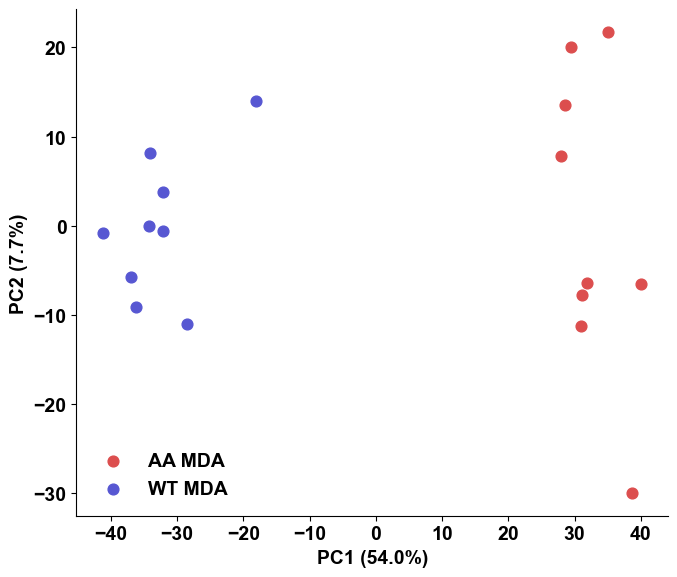

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))

# Colors (RGB -> 0–1)
COL_WT = (87/255, 87/255, 210/255)     # Control / WT
COL_AA = (220/255, 78/255, 78/255)     # Acid adapted / AA

# Condition label mapping (old -> new) + color mapping
label_map = {
    "Acid adapted": "AA MDA",
    "Control": "WT MDA",
}
color_map = {
    "Acid adapted": COL_AA,
    "Control": COL_WT,
}

for cond, sub in pc_df.groupby("Condition"):
    ax.scatter(
        sub.PC1,
        sub.PC2,
        label=label_map.get(cond, cond),
        color=color_map.get(cond, "k"),
        s=60
        )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.legend(frameon=False, loc="lower left")

plt.tight_layout()

pca_fig_path = FIGURE_DIR / "proteomics_pca_no_imputation_pc1_pc2.tiff"
fig.savefig(pca_fig_path, dpi=400, transparent=True)
print(f"Saved: {pca_fig_path.resolve()}")

plt.show()


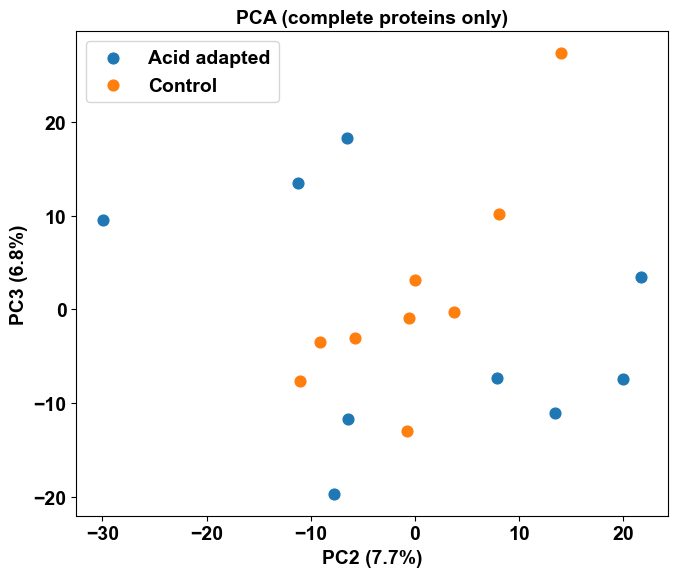

In [7]:
plt.figure(figsize=(7, 6))
for cond, sub in pc_df.groupby("Condition"):
    plt.scatter(sub.PC2, sub.PC3, label=cond, s=60)

# for name, row in pc_df.iterrows():
#     plt.text(row.PC2, row.PC3, name, fontsize=8)

plt.xlabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.ylabel(f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)")
plt.title("PCA (complete proteins only)")
plt.legend()
# plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 2) Pairwise sample correlation (complete proteins only)

Saved: /home/bnair/Desktop/analysis/aacs_proteomics/output/figures/proteomics_sample_correlation_heatmap.tiff


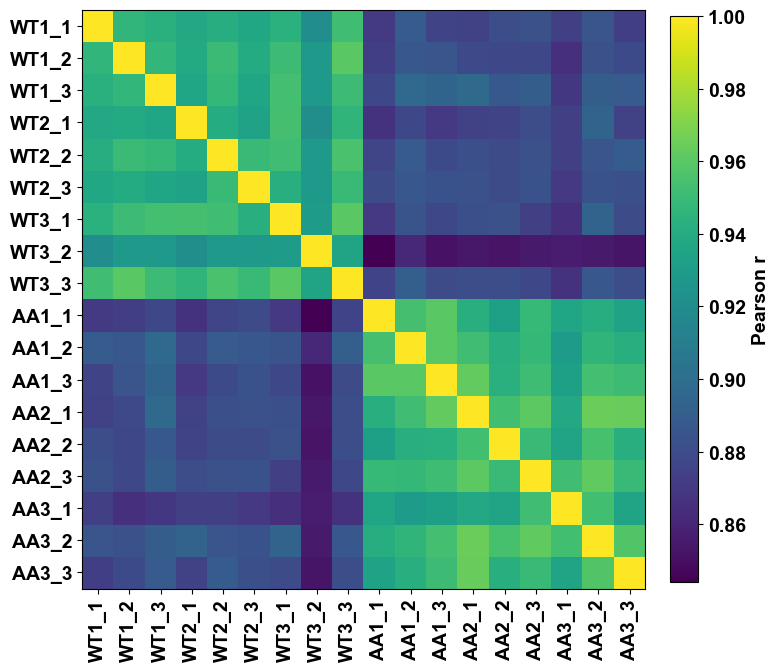

In [9]:
# Build correlation matrix
corr = X_proc.corr(method="pearson")

# Build mapping: C_1..C_9 -> WT1_1..WT3_3 (bio 1-3, tech 1-3)
wt_labels = [f"WT{bio}_{tech}" for bio in range(1, 4) for tech in range(1, 4)]
wt_map = {f"C_{i}": wt_labels[i-1] for i in range(1, 10)}  # C_1..C_9

# (Optional) do the same for AA_1..AA_9 -> AA1_1..AA3_3
aa_labels = [f"AA{bio}_{tech}" for bio in range(1, 4) for tech in range(1, 4)]
aa_map = {f"AA_{i}": aa_labels[i-1] for i in range(1, 10)}

rename_map = {**wt_map, **aa_map}

corr_plot = corr.rename(index=rename_map, columns=rename_map)

plt.figure(figsize=(8, 7))
im = plt.imshow(corr_plot.values, aspect="auto")
plt.colorbar(im, fraction=0.046, pad=0.04, label="Pearson r")

plt.xticks(range(len(corr_plot.columns)), corr_plot.columns, rotation=90)
plt.yticks(range(len(corr_plot.index)), corr_plot.index)
plt.tight_layout()

corr_fig_path = FIGURE_DIR / "proteomics_sample_correlation_heatmap.tiff"
plt.savefig(corr_fig_path, dpi=400, transparent=True, bbox_inches="tight")
print(f"Saved: {corr_fig_path.resolve()}")
plt.show()


## 3) Boxplots of intensities per sample

Boxplots use the processed data **without filtering**, reflecting real missingness.


/tmp/ipykernel_164301/1550268265.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Saved: /home/bnair/Desktop/analysis/aacs_proteomics/output/figures/proteomics_intensity_boxplots.tiff


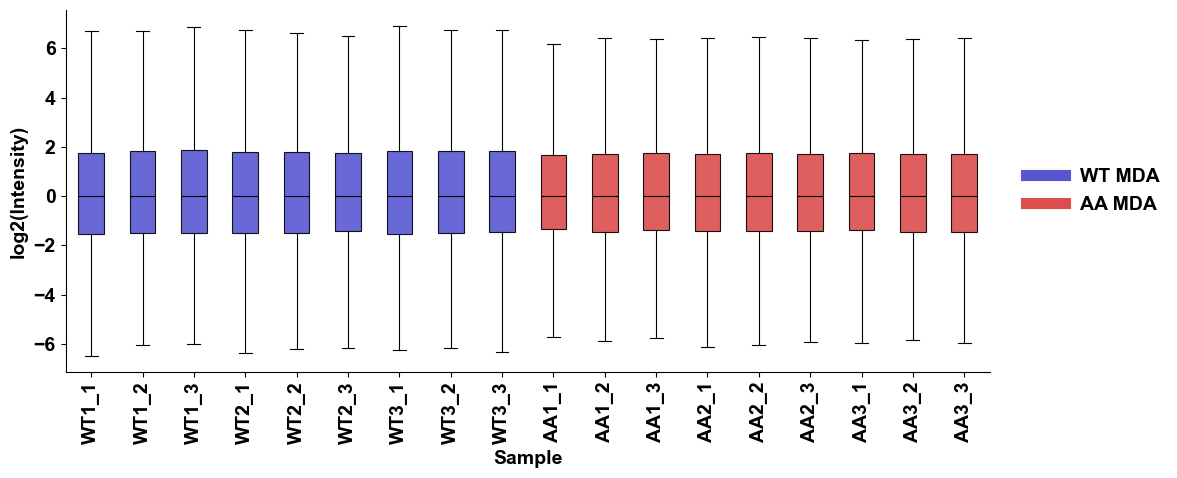

In [10]:
# Build mapping (same as above)
wt_labels = [f"WT{bio}_{tech}" for bio in range(1, 4) for tech in range(1, 4)]
wt_map = {f"C_{i}": wt_labels[i-1] for i in range(1, 10)}

aa_labels = [f"AA{bio}_{tech}" for bio in range(1, 4) for tech in range(1, 4)]
aa_map = {f"AA_{i}": aa_labels[i-1] for i in range(1, 10)}

rename_map = {**wt_map, **aa_map}

plot_labels = [rename_map.get(c, c) for c in X_proc.columns]

COL_WT = (87/255, 87/255, 210/255)
COL_AA = (220/255, 78/255, 78/255)
box_colors = [COL_WT if str(c).startswith("C_") else COL_AA for c in X_proc.columns]

fig, ax = plt.subplots(figsize=(12, 5))

bp = ax.boxplot(
    [X_proc[c].dropna().values for c in X_proc.columns],
    labels=plot_labels,
    showfliers=False,
    patch_artist=True,
)

for patch, col in zip(bp["boxes"], box_colors):
    patch.set_facecolor(col)
    patch.set_alpha(0.9)
    patch.set_edgecolor("black")
    patch.set_linewidth(0.8)

for k in ["whiskers", "caps", "medians"]:
    for line in bp[k]:
        line.set_color("black")
        line.set_linewidth(0.8)

ax.set_xticklabels(plot_labels, rotation=90)
ax.set_xlabel("Sample")
ax.set_ylabel("log2(Intensity)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

ax.legend(
    handles=[plt.Line2D([0],[0], color=COL_WT, lw=8, label="WT MDA"),
             plt.Line2D([0],[0], color=COL_AA, lw=8, label="AA MDA")],
    frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout()
boxplot_fig_path = FIGURE_DIR / "proteomics_intensity_boxplots.tiff"
fig.savefig(boxplot_fig_path, dpi=400, transparent=True, bbox_inches="tight")
print(f"Saved: {boxplot_fig_path.resolve()}")
plt.show()


## Session provenance
For GitHub or Zenodo release, consider recording the exact Python package versions used to execute this notebook and placing the input file under `data/OmicsQ/` with the same filename referenced above. This makes the repository rerunnable without editing downstream analysis cells.
